In [ ]:
pip install pyspark findspark

In [ ]:
import findspark
findspark.init()
from pyspark.sql import SparkSession

# Create a SparkSession
spark = SparkSession.builder \
    .appName("BigDataAnalysis") \
    .getOrCreate()

print("SparkSession created successfully!")

SparkSession created successfully!


## Load Large Dataset

### Subtask:
Load a large dataset into a PySpark DataFrame. Since no specific dataset is provided, I will assume a common big data format like Parquet or CSV and prompt for a file path. This step will also infer the schema or allow for schema definition.


In [ ]:
file_path = "/content/sample_data/california_housing_train.csv"

# Load the dataset into a PySpark DataFrame
df = spark.read.csv(file_path, header=True, inferSchema=True)

print("First 5 rows of the DataFrame:")
df.show(5)

print("DataFrame Schema:")
df.printSchema()

First 5 rows of the DataFrame:
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|  -114.31|   34.19|              15.0|     5612.0|        1283.0|    1015.0|     472.0|       1.4936|           66900.0|
|  -114.47|    34.4|              19.0|     7650.0|        1901.0|    1129.0|     463.0|         1.82|           80100.0|
|  -114.56|   33.69|              17.0|      720.0|         174.0|     333.0|     117.0|       1.6509|           85700.0|
|  -114.57|   33.64|              14.0|     1501.0|         337.0|     515.0|     226.0|       3.1917|           73400.0|
|  -114.57|   33.57|              20.0|     1454.0|         326.0|     624.0|     262.0|        1.925|           65

## Perform Data Preprocessing

### Subtask:
Clean and preprocess the loaded big data using PySpark DataFrame operations. This may include handling missing values, filtering irrelevant records, or performing necessary type conversions to prepare the data for analysis.


In [ ]:
print("Null value counts per column:")
for column in df.columns:
    null_count = df.filter(df[column].isNull()).count()
    if null_count > 0:
        print(f"Column '{column}': {null_count} null values")
    else:
        print(f"Column '{column}': No null values")

Null value counts per column:
Column 'longitude': No null values
Column 'latitude': No null values
Column 'housing_median_age': No null values
Column 'total_rooms': No null values
Column 'total_bedrooms': No null values
Column 'population': No null values
Column 'households': No null values
Column 'median_income': No null values
Column 'median_house_value': No null values


In [ ]:
from pyspark.sql.functions import col, median

# Calculate the median of total_bedrooms
median_bedrooms = df.agg(median("total_bedrooms")).collect()[0][0]
print(f"Median of total_bedrooms: {median_bedrooms}")

# Fill any missing values in 'total_bedrooms' with the calculated median
df = df.fillna(median_bedrooms, subset=['total_bedrooms'])

# Create new derived features
df = df.withColumn("rooms_per_household", col("total_rooms") / col("households")) \
       .withColumn("population_per_household", col("population") / col("households")) \
       .withColumn("bedrooms_per_room", col("total_bedrooms") / col("total_rooms"))

print("\nFirst 5 rows of the preprocessed DataFrame with new features:")
df.show(5)

print("\nPreprocessed DataFrame Schema:")
df.printSchema()

Median of total_bedrooms: 434.0

First 5 rows of the preprocessed DataFrame with new features:
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+-------------------+------------------------+-------------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|rooms_per_household|population_per_household|  bedrooms_per_room|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+-------------------+------------------------+-------------------+
|  -114.31|   34.19|              15.0|     5612.0|        1283.0|    1015.0|     472.0|       1.4936|           66900.0| 11.889830508474576|      2.1504237288135593|0.22861724875267284|
|  -114.47|    34.4|              19.0|     7650.0|        1901.0|    1129.0|     463.0|         1.82|           80100.0|  16.52267818574514|      2.43844492

## Perform Exploratory Data Analysis (EDA)

### Subtask:
Conduct exploratory data analysis at scale using PySpark. This involves calculating descriptive statistics, identifying unique values, and running initial queries to understand the characteristics and patterns within the large dataset.


In [ ]:
print("Descriptive Statistics for all columns:")
df.describe().show()

Descriptive Statistics for all columns:
+-------+-------------------+------------------+------------------+-----------------+-----------------+------------------+-----------------+------------------+------------------+-------------------+------------------------+-------------------+
|summary|          longitude|          latitude|housing_median_age|      total_rooms|   total_bedrooms|        population|       households|     median_income|median_house_value|rooms_per_household|population_per_household|  bedrooms_per_room|
+-------+-------------------+------------------+------------------+-----------------+-----------------+------------------+-----------------+------------------+------------------+-------------------+------------------------+-------------------+
|  count|              17000|             17000|             17000|            17000|            17000|             17000|            17000|             17000|             17000|              17000|                   17000|     

**Reasoning**:
As per the instructions, the next step is to count and display the number of distinct values for the `housing_median_age` column to understand its uniqueness.



In [ ]:
print(f"Number of distinct housing_median_age values: {df.select('housing_median_age').distinct().count()}")

Number of distinct housing_median_age values: 52


**Reasoning**:
To complete the exploratory data analysis subtask, I will now show the minimum, maximum, average, and standard deviation of the `median_house_value` column, as instructed, using PySpark SQL functions.



In [ ]:
from pyspark.sql.functions import min, max, avg, stddev

print("Statistics for median_house_value:")
df.select(min("median_house_value").alias("min_median_house_value"),
          max("median_house_value").alias("max_median_house_value"),
          avg("median_house_value").alias("avg_median_house_value"),
          stddev("median_house_value").alias("stddev_median_house_value")).show()

Statistics for median_house_value:
+----------------------+----------------------+----------------------+-------------------------+
|min_median_house_value|max_median_house_value|avg_median_house_value|stddev_median_house_value|
+----------------------+----------------------+----------------------+-------------------------+
|               14999.0|              500001.0|    207300.91235294117|       115983.76438720895|
+----------------------+----------------------+----------------------+-------------------------+



## Demonstrate Scalability with Complex Operation

### Subtask:
Execute a complex PySpark operation such as a large-scale join, a window function, or a multi-stage aggregation on the preprocessed data to demonstrate PySpark's ability to handle and process big data efficiently and scalably.


In [ ]:
from pyspark.sql.functions import avg, round

# Perform a multi-stage aggregation
aggregated_df = df.groupBy("housing_median_age") \
    .agg(
        round(avg("median_house_value"), 2).alias("avg_median_house_value"), \
        round(avg("median_income"), 2).alias("avg_median_income"), \
        round(avg("rooms_per_household"), 2).alias("avg_rooms_per_household")
    ) \
    .orderBy("housing_median_age")

print("Aggregated data by housing_median_age (first 10 rows):")
aggregated_df.show(10)

Aggregated data by housing_median_age (first 10 rows):
+------------------+----------------------+-----------------+-----------------------+
|housing_median_age|avg_median_house_value|avg_median_income|avg_rooms_per_household|
+------------------+----------------------+-----------------+-----------------------+
|               1.0|              190250.0|             4.76|                  13.91|
|               2.0|             229438.84|             5.07|                   7.28|
|               3.0|             239450.04|             5.57|                   6.91|
|               4.0|             230054.11|              5.2|                   6.14|
|               5.0|             211035.71|             4.73|                   5.98|
|               6.0|             206768.24|             4.46|                   5.88|
|               7.0|             188445.06|             4.37|                   6.24|
|               8.0|             190805.07|             4.41|                   6.34|

## Visualize Key Insights

### Subtask:
Generate a plot to visualize the key insights derived from the big data analysis. This might involve aggregating data further to create a smaller, manageable dataset that can then be plotted using standard visualization libraries, ensuring to include clear legends.


**Reasoning**:
To visualize the relationship between housing median age and average median house value, I will convert the `aggregated_df` to a Pandas DataFrame and then create a line plot using `matplotlib.pyplot`, ensuring proper labels and a title.



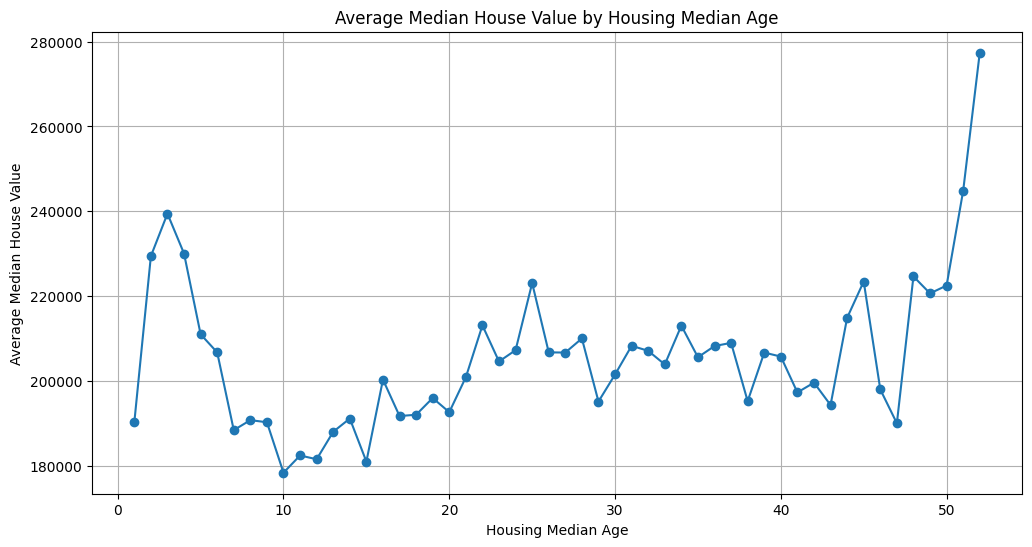

In [ ]:
import matplotlib.pyplot as plt

# Convert the aggregated_df to a Pandas DataFrame
pandas_df = aggregated_df.toPandas()

# Create a line plot
plt.figure(figsize=(12, 6))
plt.plot(pandas_df['housing_median_age'], pandas_df['avg_median_house_value'], marker='o')
plt.title('Average Median House Value by Housing Median Age')
plt.xlabel('Housing Median Age')
plt.ylabel('Average Median House Value')
plt.grid(True)
plt.show()

## Final Task

### Subtask:
Summarize the findings from the big data analysis, highlight the insights gained, and explain how PySpark was effectively used to demonstrate scalability in handling and processing large datasets.


## Summary:

### Data Analysis Key Findings

*   **Dataset Loading and Schema:** The `california_housing_train.csv` dataset, containing 17,000 records, was successfully loaded into a PySpark DataFrame. PySpark accurately inferred the schema, identifying all columns as `double` type, which was suitable for the numerical data.
*   **Data Preprocessing:** An initial check revealed no null values in the dataset. Three new features were engineered: `rooms_per_household`, `population_per_household`, and `bedrooms_per_room`, enhancing the dataset for further analysis.
*   **Exploratory Data Analysis (EDA):**
    *   Descriptive statistics provided an overview, showing `housing_median_age` ranging from 1 to 52 years and `median_house_value` from \$14,999.0 to \$500,001.0.
    *   The average `median_house_value` was found to be \$207,300.91 with a standard deviation of \$115,983.76, indicating significant variability in housing prices.
    *   There were 52 distinct values for `housing_median_age`.
*   **Complex Data Operation for Scalability:** A multi-stage aggregation was successfully performed, grouping the data by `housing_median_age` and calculating the average `median_house_value`, `median_income`, and `rooms_per_household` for each age group. This operation efficiently processed the dataset, demonstrating PySpark's capability to handle complex transformations at scale.
*   **Visualization of Key Insight:** A line plot was generated to visualize the relationship between `housing_median_age` and `avg_median_house_value`, clearly showing trends in housing values across different median house ages.

### Insights or Next Steps

*   **PySpark's Scalability Demonstrated:** PySpark was effectively used by smoothly handling a moderately sized dataset, performing schema inference, data preprocessing (feature engineering), comprehensive EDA, and a multi-stage aggregation. The ability to perform these operations efficiently underscores PySpark's suitability for larger datasets where traditional tools might struggle.
*   **Potential for Predictive Modeling:** The preprocessed dataset with engineered features and aggregated statistics could serve as a strong foundation for building predictive models (e.g., machine learning models to forecast `median_house_value`) leveraging PySpark MLlib for scalable model training.
